In [143]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Regresión Lineal — Battery vs Gaming Dataset

**Objetivo:** Predecir el nivel de batería restante (`Battery_End_%`) al terminar una sesión de juego, en función del tiempo de sesión, FPS, batería inicial, juego y dispositivo.

**Dataset:** `battery_vs_gaming_dataset_medium.csv` — 1000 registros de sesiones de juego en dispositivos iOS y Android.

## 1. Carga del Dataset

In [123]:
df = pd.read_csv("battery_vs_gaming_dataset_medium.csv")

print(f"Shape: {df.shape}")
print(f"\nColumnas: {list(df.columns)}")
df.head(10)

Shape: (1000, 7)

Columnas: ['Game_Name', 'Device_Type', 'Session_Time_Minutes', 'FPS', 'Battery_Start_%', 'Battery_End_%', 'Battery_Drop_%']


,Game_Name,Device_Type,Session_Time_Minutes,FPS,Battery_Start_%,Battery_End_%,Battery_Drop_%
0,Free Fire,iOS,86,90,53,40,13
1,Asphalt 9,Android,15,30,63,43,20
2,Free Fire,iOS,164,120,80,50,30
3,Call of Duty,Android,15,45,64,41,23
4,BGMI,iOS,174,30,75,56,19
5,Asphalt 9,Android,172,45,42,25,17
6,Free Fire,iOS,140,90,36,15,21
7,Free Fire,iOS,66,120,64,58,6
8,Free Fire,Android,147,45,92,83,9
9,Asphalt 9,iOS,12,90,96,61,35


## 2. Análisis Exploratorio (EDA)

### 2.1 Información general y valores nulos

In [124]:
df.info()
print("\n--- Valores nulos ---")
print(df.isnull().sum())

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 7 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   Game_Name             1000 non-null   str  
 1   Device_Type           1000 non-null   str  
 2   Session_Time_Minutes  1000 non-null   int64
 3   FPS                   1000 non-null   int64
 4   Battery_Start_%       1000 non-null   int64
 5   Battery_End_%         1000 non-null   int64
 6   Battery_Drop_%        1000 non-null   int64
dtypes: int64(5), str(2)
memory usage: 54.8 KB

--- Valores nulos ---
Game_Name               0
Device_Type             0
Session_Time_Minutes    0
FPS                     0
Battery_Start_%         0
Battery_End_%           0
Battery_Drop_%          0
dtype: int64


In [125]:
df['Game_Name'].value_counts()

Game_Name
Genshin Impact    208
Free Fire         203
Asphalt 9         200
BGMI              198
Call of Duty      191
Name: count, dtype: int64

In [126]:
df['FPS'].value_counts()

FPS
90     217
45     217
120    192
60     191
30     183
Name: count, dtype: int64

In [127]:
df['Device_Type'].value_counts()

Device_Type
Android    509
iOS        491
Name: count, dtype: int64

In [128]:
df.describe()

,Session_Time_Minutes,FPS,Battery_Start_%,Battery_End_%,Battery_Drop_%
count,1000.00000,1000.000000,1000.000000,1000.000000,1000.00000
mean,94.68900,69.285000,65.532000,42.947000,22.71100
std,50.79595,31.856375,20.590652,22.917841,10.23857
min,10.00000,30.000000,30.000000,0.000000,5.00000
25%,51.00000,45.000000,48.000000,25.000000,14.00000
50%,95.00000,60.000000,66.500000,43.000000,23.00000
75%,139.00000,90.000000,83.000000,61.000000,31.00000
max,180.00000,120.000000,100.000000,93.000000,40.00000


### 2.3 Distribución de variables categóricas

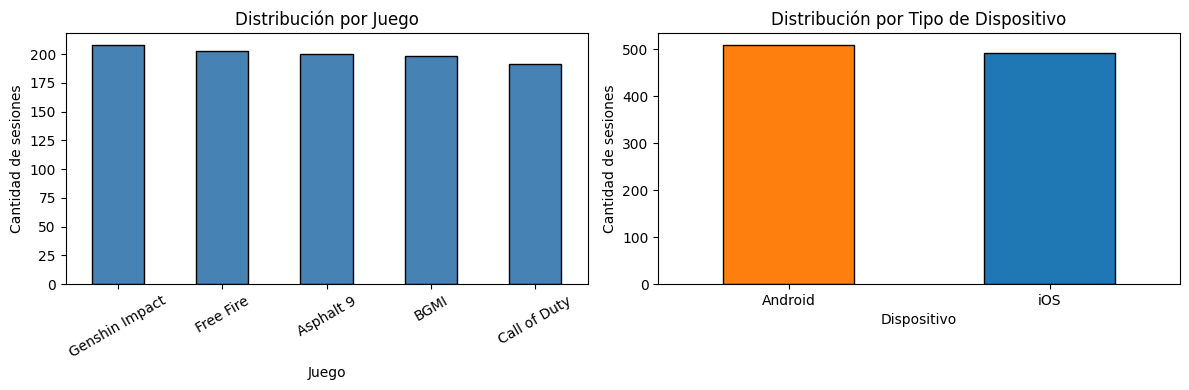

In [129]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df["Game_Name"].value_counts().plot(kind="bar", ax=axes[0], color="steelblue", edgecolor="black")
axes[0].set_title("Distribución por Juego")
axes[0].set_xlabel("Juego")
axes[0].set_ylabel("Cantidad de sesiones")
axes[0].tick_params(axis="x", rotation=30)

df["Device_Type"].value_counts().plot(kind="bar", ax=axes[1], color=["#FF7F0E", "#1F77B4"], edgecolor="black")
axes[1].set_title("Distribución por Tipo de Dispositivo")
axes[1].set_xlabel("Dispositivo")
axes[1].set_ylabel("Cantidad de sesiones")
axes[1].tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.show()

### 2.4 Distribución de variables numéricas (histogramas)

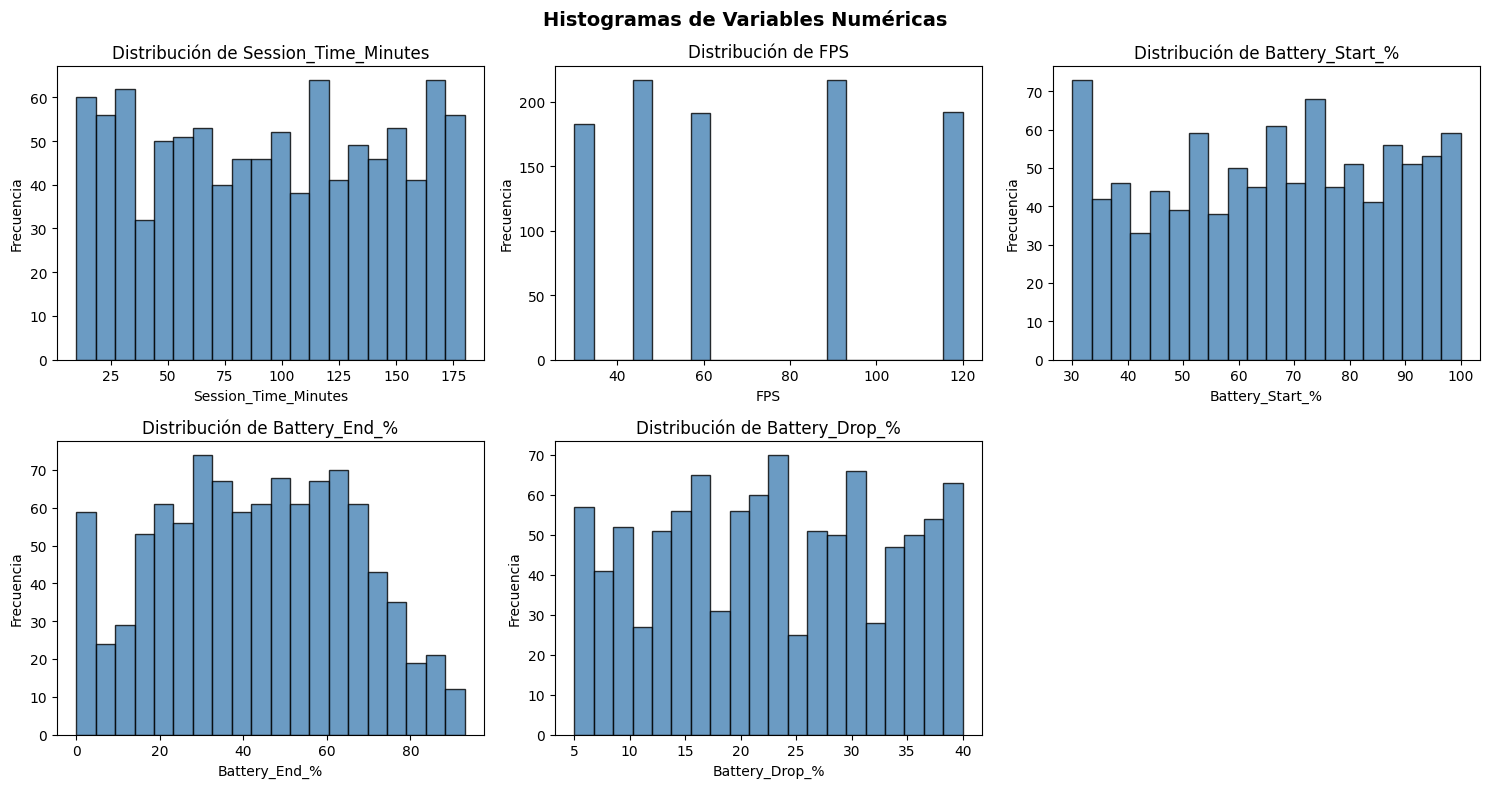

In [130]:
num_cols = ["Session_Time_Minutes", "FPS", "Battery_Start_%", "Battery_End_%", "Battery_Drop_%"]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    axes[i].hist(df[col], bins=20, color="steelblue", edgecolor="black", alpha=0.8)
    axes[i].set_title(f"Distribución de {col}")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Frecuencia")

axes[-1].axis("off")
plt.suptitle("Histogramas de Variables Numéricas", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

### 2.5 Boxplots — Battery Drop por juego y dispositivo

C:\Users\jenar\AppData\Local\Temp\ipykernel_16748\3123084861.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="Game_Name", y="Battery_Drop_%", palette="Set2", ax=axes[0])
C:\Users\jenar\AppData\Local\Temp\ipykernel_16748\3123084861.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="Device_Type", y="Battery_Drop_%", palette="Set1", ax=axes[1])


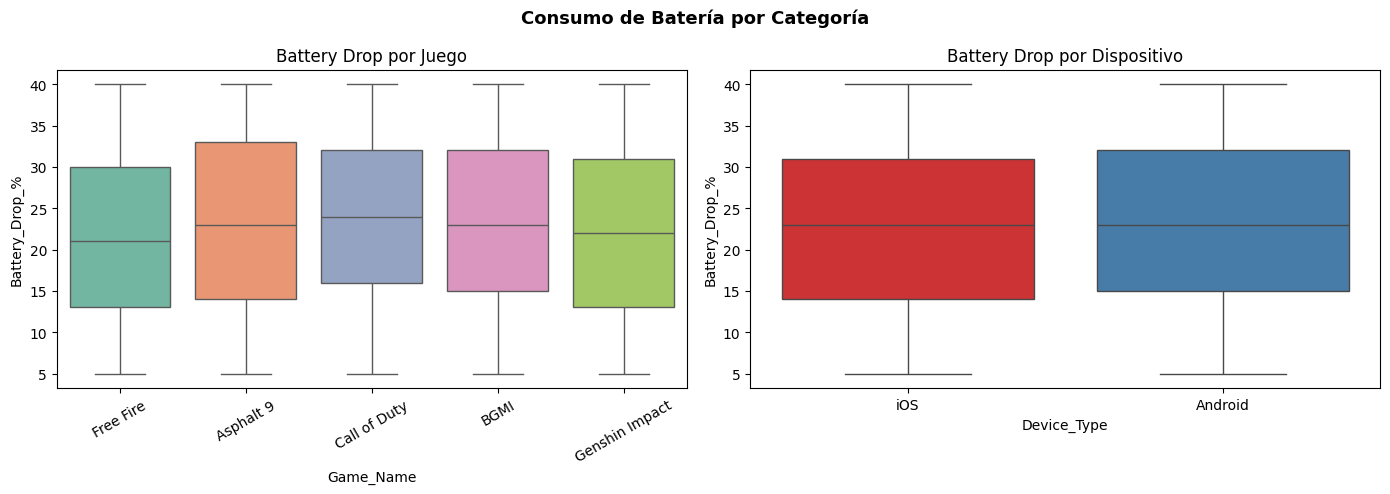

In [131]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=df, x="Game_Name", y="Battery_Drop_%", palette="Set2", ax=axes[0])
axes[0].set_title("Battery Drop por Juego")
axes[0].tick_params(axis="x", rotation=30)

sns.boxplot(data=df, x="Device_Type", y="Battery_Drop_%", palette="Set1", ax=axes[1])
axes[1].set_title("Battery Drop por Dispositivo")

plt.suptitle("Consumo de Batería por Categoría", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

### 2.6 Heatmap de correlaciones

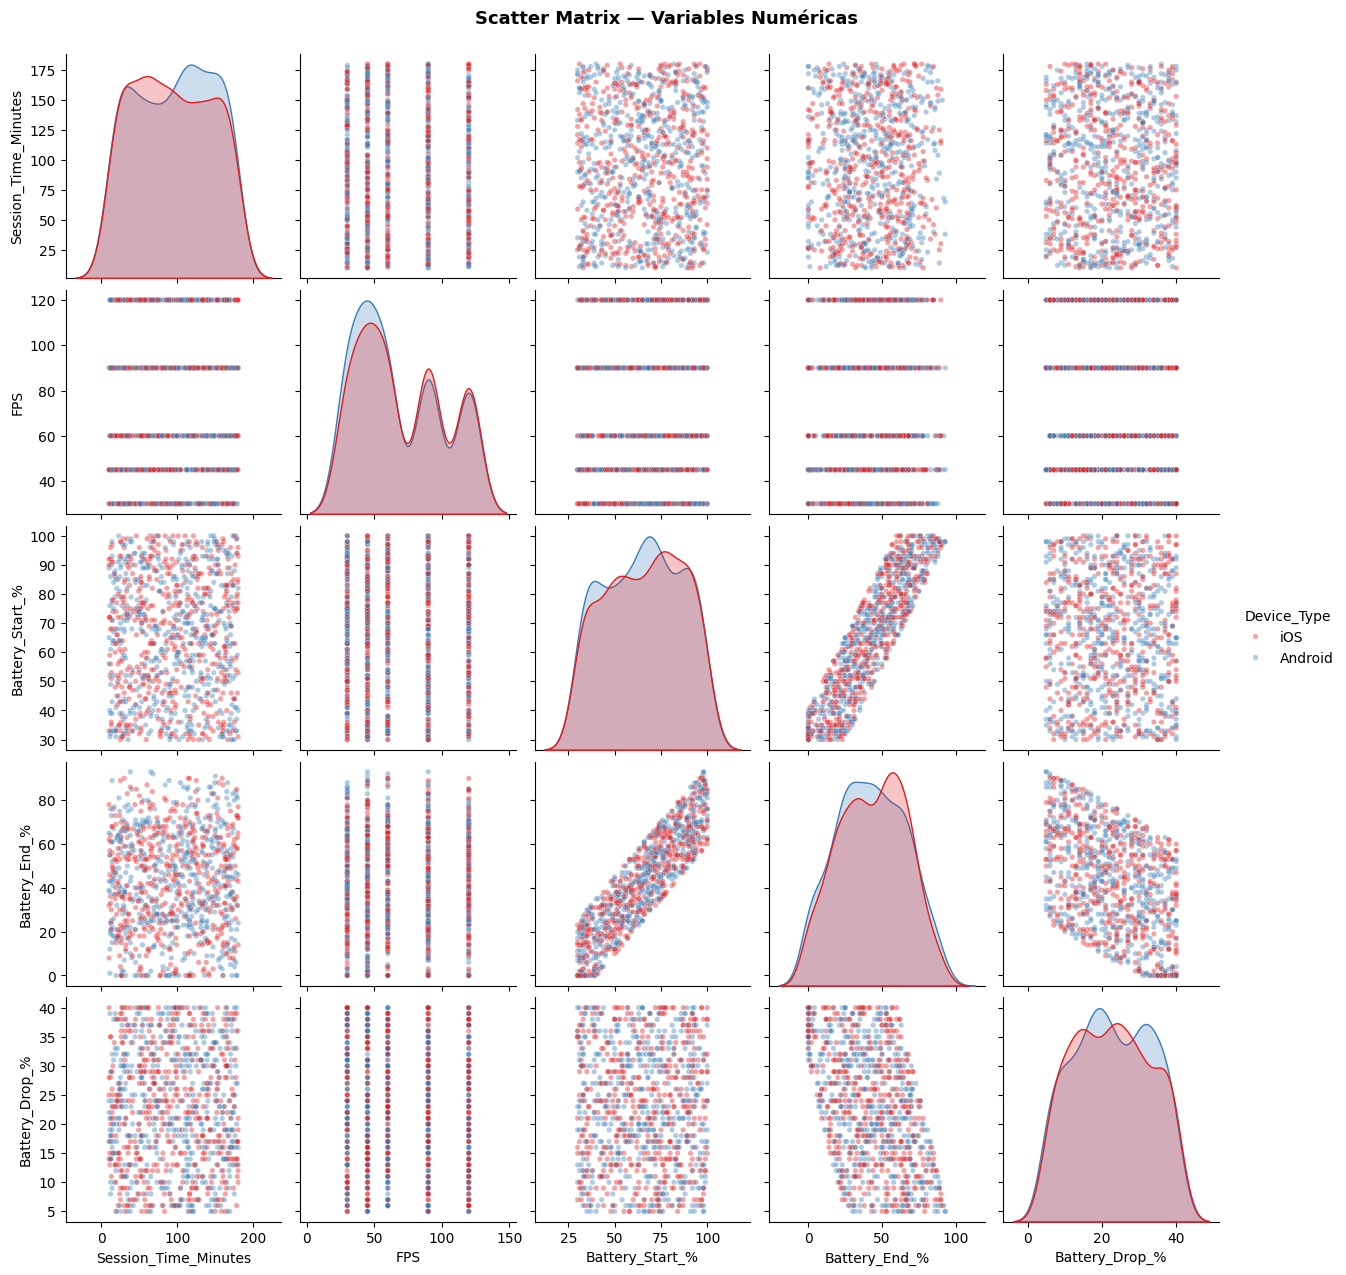

In [132]:
g = sns.pairplot(
    df[num_cols + ["Device_Type"]],
    hue="Device_Type",
    diag_kind="kde",
    plot_kws={"alpha": 0.4, "s": 15},
    palette="Set1"
)
g.figure.suptitle("Scatter Matrix — Variables Numéricas", y=1.02, fontsize=13, fontweight="bold")
plt.show()

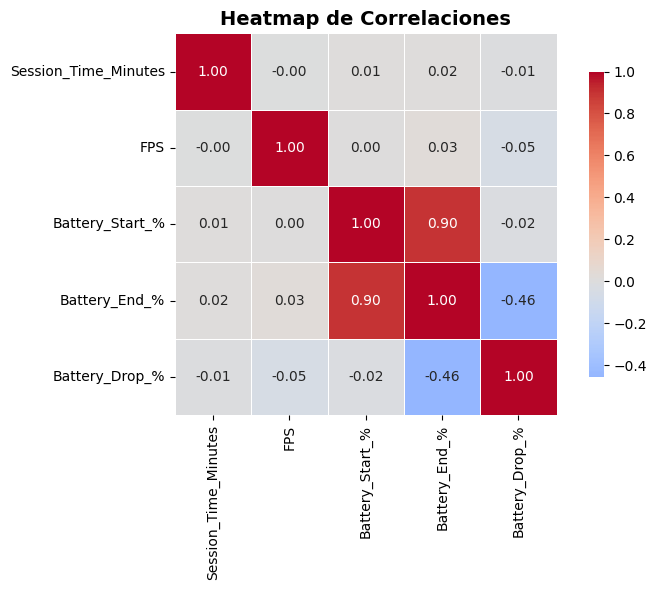


Correlaciones con Battery_Drop_%:
Battery_Drop_%          1.000000
Session_Time_Minutes   -0.006569
Battery_Start_%        -0.018823
FPS                    -0.051380
Battery_End_%          -0.455641
Name: Battery_Drop_%, dtype: float64


In [133]:
plt.figure(figsize=(8, 6))
corr = df[num_cols].corr()

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8}
)
plt.title("Heatmap de Correlaciones", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

print("\nCorrelaciones con Battery_Drop_%:")
print(corr["Battery_Drop_%"].sort_values(ascending=False))

### 2.7 Scatter Matrix (Pairplot)

### 2.8 VIF — Factor de Inflación de Varianza (variables numéricas)

Un VIF > 10 es señal de multicolinealidad problemática; entre 5 y 10 es moderada.

                 Feature      VIF
         Battery_Start_% 6.506210
    Session_Time_Minutes 3.936077
         Device_Type_iOS 1.911958
                  FPS_90 1.888840
                  FPS_45 1.888271
                  FPS_60 1.867939
     Game_Name_Free Fire 1.810640
                 FPS_120 1.808015
Game_Name_Genshin Impact 1.806242
          Game_Name_BGMI 1.770659
  Game_Name_Call of Duty 1.735686

VIF > 10 → alta multicolinealidad | 5–10 → moderada | < 5 → aceptable


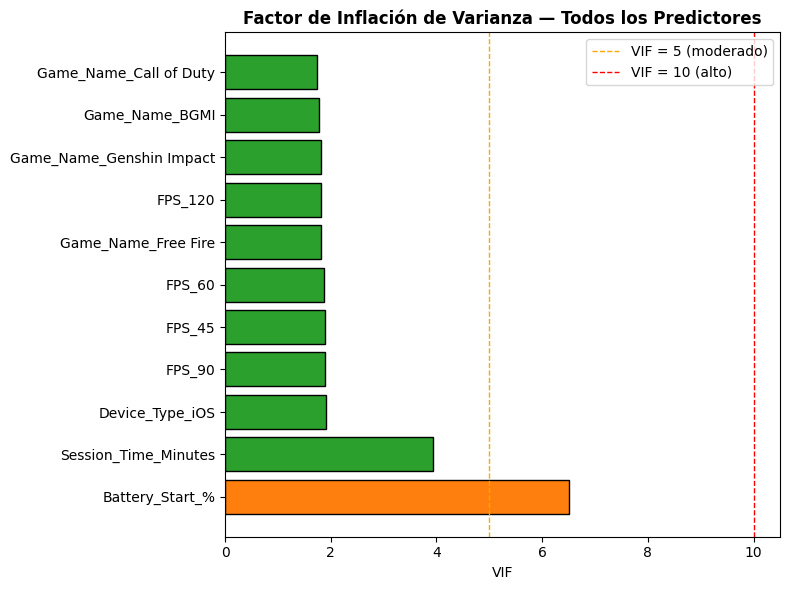

In [134]:
df_model = pd.get_dummies(
    df,
    columns=["Game_Name", "Device_Type", "FPS"],
    drop_first=True
).drop(columns=["Battery_End_%", "Battery_Drop_%"])

vif_eda = pd.DataFrame({
    "Feature": df_model.columns,
    "VIF": [variance_inflation_factor(df_model.values.astype(float), i)
            for i in range(df_model.shape[1])]
}).sort_values("VIF", ascending=False)

print(vif_eda.to_string(index=False))
print("\nVIF > 10 → alta multicolinealidad | 5–10 → moderada | < 5 → aceptable")

fig, ax = plt.subplots(figsize=(8, 6))
colors = ["#d62728" if v > 10 else "#ff7f0e" if v > 5 else "#2ca02c"
          for v in vif_eda["VIF"]]
ax.barh(vif_eda["Feature"], vif_eda["VIF"], color=colors, edgecolor="black")
ax.axvline(5,  color="orange", linestyle="--", linewidth=1, label="VIF = 5 (moderado)")
ax.axvline(10, color="red",    linestyle="--", linewidth=1, label="VIF = 10 (alto)")
ax.set_xlabel("VIF")
ax.set_title("Factor de Inflación de Varianza — Todos los Predictores", fontweight="bold")
ax.legend()
plt.tight_layout()
plt.show()

## 3. Preparación de Datos

Convertimos las variables categóricas (`Game_Name`, `Device_Type`) a variables dummy (one-hot encoding) y separamos features de la variable objetivo.

In [135]:
df_model.columns

Index(['Session_Time_Minutes', 'Battery_Start_%', 'Game_Name_BGMI',
       'Game_Name_Call of Duty', 'Game_Name_Free Fire',
       'Game_Name_Genshin Impact', 'Device_Type_iOS', 'FPS_45', 'FPS_60',
       'FPS_90', 'FPS_120'],
      dtype='str')

In [136]:
# Battery_Drop_% = Battery_Start_% - Battery_End_% → derivada del target, se excluye
X = df_model
y = df["Battery_End_%"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"\nTrain: {X_train.shape} | Test: {X_test.shape}")
print(f"\nVariable objetivo : Battery_End_%")
print(f"Features usadas   : {list(X.columns)}")


Train: (800, 11) | Test: (200, 11)

Variable objetivo : Battery_End_%
Features usadas   : ['Session_Time_Minutes', 'Battery_Start_%', 'Game_Name_BGMI', 'Game_Name_Call of Duty', 'Game_Name_Free Fire', 'Game_Name_Genshin Impact', 'Device_Type_iOS', 'FPS_45', 'FPS_60', 'FPS_90', 'FPS_120']


## 4. Entrenamiento del Modelo de Regresión Lineal

In [137]:
model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

n, p = X_test.shape
r2      = r2_score(y_test, y_pred)
r2_adj  = 1 - (1 - r2) * (n - 1) / (n - p - 1)
rmse    = np.sqrt(mean_squared_error(y_test, y_pred))
mae     = mean_absolute_error(y_test, y_pred)

print("=== Métricas en Test ===")
print(f"  R²          : {r2:.4f}")
print(f"  R² ajustado : {r2_adj:.4f}")
print(f"  RMSE        : {rmse:.4f}")
print(f"  MAE         : {mae:.4f}")

=== Métricas en Test ===
  R²          : 0.8111
  R² ajustado : 0.8001
  RMSE        : 9.9024
  MAE         : 8.5621


## 5. Diagnóstico del Modelo


### 5.1 Predicho vs Real

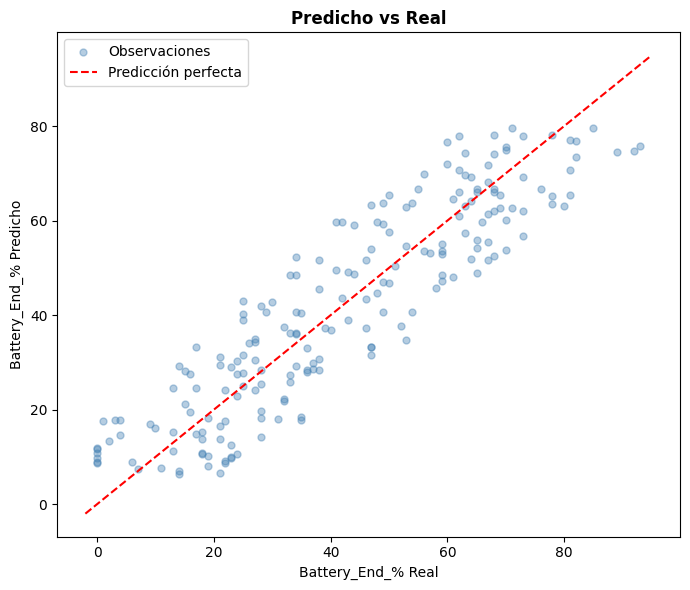

In [138]:
residuals = y_test - y_pred

fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(y_test, y_pred, alpha=0.4, color="steelblue", s=25, label="Observaciones")
lims = [min(y_test.min(), y_pred.min()) - 2, max(y_test.max(), y_pred.max()) + 2]
ax.plot(lims, lims, "r--", linewidth=1.5, label="Predicción perfecta")
ax.set_xlabel("Battery_End_% Real")
ax.set_ylabel("Battery_End_% Predicho")
ax.set_title("Predicho vs Real", fontweight="bold")
ax.legend()
plt.tight_layout()
plt.show()

### 5.2 Residuales vs Valores Ajustados (homocedasticidad)

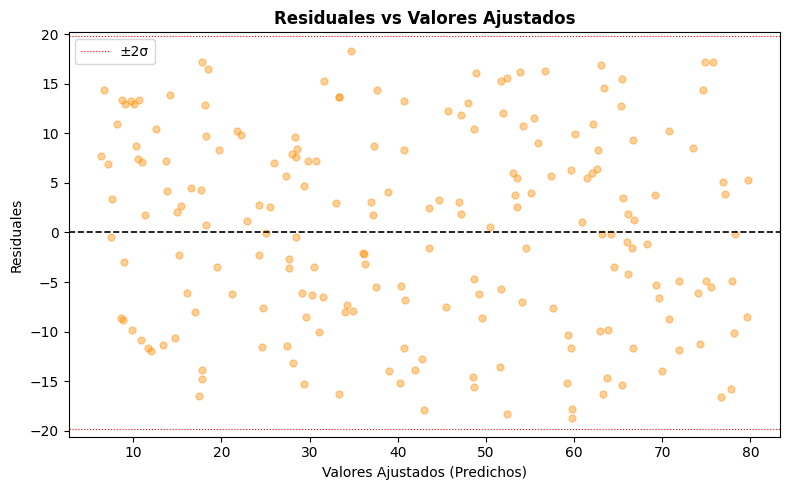

In [139]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(y_pred, residuals, alpha=0.4, color="darkorange", s=25)
ax.axhline(0, color="black", linewidth=1.2, linestyle="--")
ax.set_xlabel("Valores Ajustados (Predichos)")
ax.set_ylabel("Residuales")
ax.set_title("Residuales vs Valores Ajustados", fontweight="bold")

# banda de ±2*std para referencia
std_res = residuals.std()
ax.axhline( 2 * std_res, color="red", linewidth=0.8, linestyle=":", label="±2σ")
ax.axhline(-2 * std_res, color="red", linewidth=0.8, linestyle=":")
ax.legend()
plt.tight_layout()
plt.show()

### 5.3 Distribución de Residuales (normalidad)

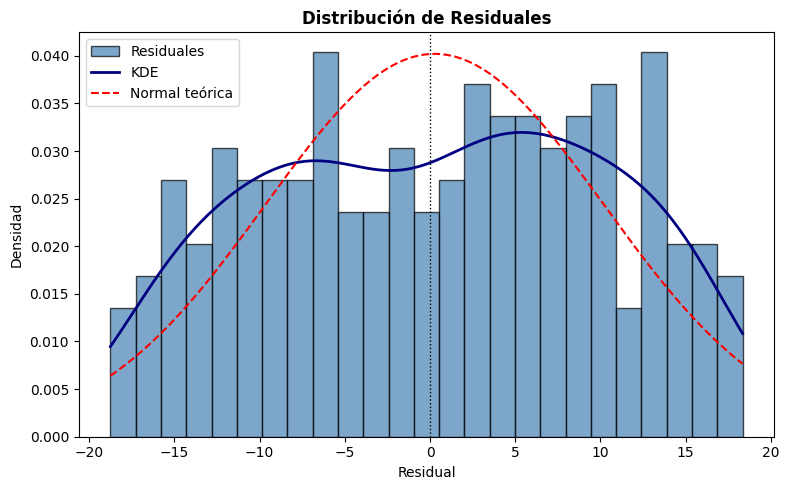

Media de residuales : 0.2693  (idealmente ≈ 0)
Std  de residuales  : 9.9236


In [140]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(residuals, bins=25, color="steelblue", edgecolor="black", alpha=0.7, density=True, label="Residuales")

# KDE encima
from scipy.stats import norm, gaussian_kde
kde = gaussian_kde(residuals)
x_range = np.linspace(residuals.min(), residuals.max(), 300)
ax.plot(x_range, kde(x_range), color="navy", linewidth=2, label="KDE")
ax.plot(x_range, norm.pdf(x_range, residuals.mean(), residuals.std()),
        color="red", linewidth=1.5, linestyle="--", label="Normal teórica")

ax.axvline(0, color="black", linewidth=1, linestyle=":")
ax.set_xlabel("Residual")
ax.set_ylabel("Densidad")
ax.set_title("Distribución de Residuales", fontweight="bold")
ax.legend()
plt.tight_layout()
plt.show()

print(f"Media de residuales : {residuals.mean():.4f}  (idealmente ≈ 0)")
print(f"Std  de residuales  : {residuals.std():.4f}")

### 5.4 Q-Q Plot (normalidad de residuales)

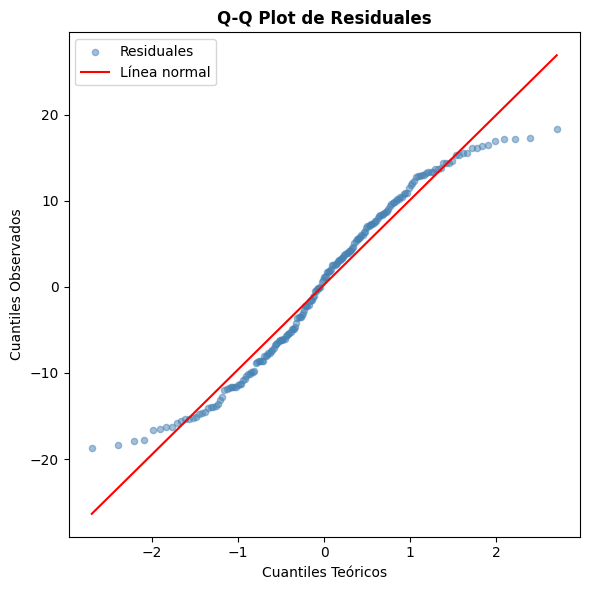

R² de la línea Q-Q: 0.9692  (más cercano a 1 → más normal)


In [141]:
from scipy.stats import probplot

fig, ax = plt.subplots(figsize=(6, 6))
(osm, osr), (slope, intercept, r) = probplot(residuals, dist="norm")
ax.scatter(osm, osr, alpha=0.5, color="steelblue", s=20, label="Residuales")
ax.plot(osm, slope * np.array(osm) + intercept, color="red", linewidth=1.5, label="Línea normal")
ax.set_xlabel("Cuantiles Teóricos")
ax.set_ylabel("Cuantiles Observados")
ax.set_title("Q-Q Plot de Residuales", fontweight="bold")
ax.legend()
plt.tight_layout()
plt.show()

print(f"R² de la línea Q-Q: {r**2:.4f}  (más cercano a 1 → más normal)")

### 5.5 Coeficientes del Modelo

In [142]:
coefs = pd.DataFrame({
    "Coeficiente": model.coef_
}, index=X.columns).sort_values("Coeficiente", ascending=False)

print(f"Intercepto: {model.intercept_:.4f}\n")
print(coefs.to_string(float_format="{:.4f}".format))

Intercepto: -25.0976

                          Coeficiente
FPS_120                        2.1630
FPS_45                         1.6535
Game_Name_Free Fire            1.2065
FPS_90                         1.1056
Battery_Start_%                1.0106
Game_Name_Genshin Impact       1.0092
FPS_60                         0.7747
Game_Name_BGMI                 0.6359
Device_Type_iOS                0.2895
Session_Time_Minutes           0.0014
Game_Name_Call of Duty        -1.2971


## Reflexion

Siendo un  a persona proactiva y despues de haber cursado el bloque de Análisis de Ciencia de Datos, decidí incluir una que otra cosa mas en esta practica del entrenamiento de una regresion lineal. Entre esas cosas agregadas, añadi un scatter matrix, un heatmap y el indicador VIR para detectar multicolinealidad entre los predictores. Tambien tuve que hacer one-hot encodign para poder ingresar valores categoricos al dataset de manera valida. Por último al momento de validar el modelo no me quede solo con los indicadores basicos de validación sino que tambien inclui gráficas del valor predicho vs el real, la distribución de los residuales, otra grafica para verificar la homocedasticidad, un Q-Q Plot y los coeficientes (o pesos) de cada predictor.

En general, esta practica fue bastante fácil pero es bueno recordad como hacer las cosas de manera correcta y precisa.